# Exploration: LOR Geometries
**GEODATA**

---

**Zweck:** Die LOR-Polygone prüfen (Abdeckung, Hierarchie, Qualität) und abgeleitete räumliche Merkmale (Fläche, Dichte, Abstand zum Zentrum) vorstellen.  
**Input:** `app_data/geo/lor_*.geojson`, `dim_region`, `fct_timegoal_region_yearly` aus `data/berlin_emergency.duckdb`.  
**Output:** Fazit zu Inhalt, Nutzen und Grenzen; Kandidaten für `03_analysis_geo`.

## Setup

In [1]:
from berlin_emergency_response.notebook import *
import duckdb
from wgnd.viz import bar, line

setup_plotting()
con = duckdb.connect(str(PATHS["db"]), read_only=True)

def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()

✓  wgnd theme activated (matplotlib · seaborn)

## Structure

### Load Polygons

Quelle: Geoportal Berlin, WFS `su_lor` (LOR, Stand 01.01.2021), Amt für Statistik Berlin-Brandenburg, CC BY 3.0 DE. `scripts/fetch_lor.py` lädt, vereinfacht (Toleranz 0,00002 Grad, etwa 2 m) und teilt nach Ebene. Wir lesen die committeten Dateien in `app_data/geo/`. Fläche und Abstände sind Näherungen (Gradwerte, auf 52,5 Grad Breite skaliert).

In [2]:
import json
import numpy as np
import shapely
from shapely import affinity
from shapely.geometry import shape

LAT0 = np.deg2rad(52.5)
KM_PER_DEG_LON, KM_PER_DEG_LAT = 111.32 * np.cos(LAT0), 110.57
ALEXANDERPLATZ = (13.4132, 52.5219)  # lon, lat, reference point for 'distance to centre'

def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))

def load_geo(level: str) -> pd.DataFrame:
    path = PATHS['app_data'] / 'geo' / f'lor_{level}.geojson'
    rows = []
    for f in json.loads(path.read_text(encoding='utf-8'))['features']:
        geom = shape(f['geometry'])
        c = geom.centroid
        rows.append({
            'region_id': f['properties']['region_id'], 'lor_name': f['properties']['region_name'],
            'geometry_type': geom.geom_type, 'parts': len(geom.geoms) if hasattr(geom, 'geoms') else 1,
            'is_valid': geom.is_valid, 'vertices': shapely.get_num_coordinates(geom),
            'area_km2': affinity.scale(geom, xfact=KM_PER_DEG_LON, yfact=KM_PER_DEG_LAT, origin=(0, 0)).area,
            'lon': c.x, 'lat': c.y,
        })
    df = pd.DataFrame(rows)
    df['dist_centre_km'] = haversine_km(df['lon'], df['lat'], *ALEXANDERPLATZ)
    df['level'] = level
    return df

LEVELS = ['prediction_area', 'district_area', 'planning_room']
df_geo = pd.concat([load_geo(lv) for lv in LEVELS], ignore_index=True)
df_files = pd.DataFrame([{'level': lv, 'file_mb': round((PATHS['app_data'] / 'geo' / f'lor_{lv}.geojson').stat().st_size / 1e6, 2)} for lv in LEVELS])
df_sum = df_geo.groupby('level').agg(regions=('region_id', 'count'), valid=('is_valid', 'sum'), multipart=('parts', lambda s: int((s > 1).sum())),
                                     vertices=('vertices', 'sum'), total_area_km2=('area_km2', 'sum')).round(0).reset_index()
show_df(df_sum.merge(df_files, on='level'))

,level,regions,valid,multipart,vertices,total_area_km2,file_mb
0,district_area,143,143,2,19887,884.00,0.41
1,planning_room,542,542,2,33519,884.00,0.75
2,prediction_area,58,58,2,13968,884.00,0.28


Alle Ebenen decken dieselbe Fläche ab (Berlin). Die Summen der Flächen müssen sich bis auf Näherungsfehler gleichen.

### Match with the Regional Data

In [3]:
df_dim = q('select region_level as level, region_id, region_name as bf_name, district_code from dim_region')
df_match = df_geo.merge(df_dim, on=['level', 'region_id'], how='outer', indicator=True)
show_df(df_match.groupby(['level', '_merge'], observed=True).size().reset_index(name='regions'))
df_names = df_match[(df_match['_merge'] == 'both') & (df_match['lor_name'].str.strip() != df_match['bf_name'].str.strip())]
show_df(df_names[['level', 'region_id', 'lor_name', 'bf_name']])

,level,_merge,regions
0,district_area,both,143
1,planning_room,both,542
2,prediction_area,both,58


,level,region_id,lor_name,bf_name
623,planning_room,11300616,Hohenschönhauser Straße,Hohenschönhausener Straße
656,planning_room,12200308,Meller Bogen,Mellerbogen
674,planning_room,12500926,Wittenau Mitte,Wittenau Süd
678,planning_room,12500930,Wittenau Süd,Wittenau Mitte


### Hierarchy

In [4]:
ids = {lv: set(df_geo.loc[df_geo['level'] == lv, 'region_id']) for lv in LEVELS}
orphans = {
    'planning rooms without district area': sum(rid[:6] not in ids['district_area'] for rid in ids['planning_room']),
    'planning rooms without prediction area': sum(rid[:4] not in ids['prediction_area'] for rid in ids['planning_room']),
    'district areas without prediction area': sum(rid[:4] not in ids['prediction_area'] for rid in ids['district_area']),
}
show_df(pd.DataFrame(orphans.items(), columns=['check', 'violations']))

,check,violations
0,planning rooms without district area,0
1,planning rooms without prediction area,0
2,district areas without prediction area,0


## Size of Regions

,level,count,mean,std,min,25%,50%,75%,max
0,district_area,143.00,6.18,6.32,0.71,2.33,4.06,7.01,42.92
1,planning_room,542.00,1.63,2.74,0.13,0.51,0.80,1.66,23.49
2,prediction_area,58.00,15.23,12.34,2.63,7.51,11.58,19.01,61.88


Text(0.5, 0, 'km²')

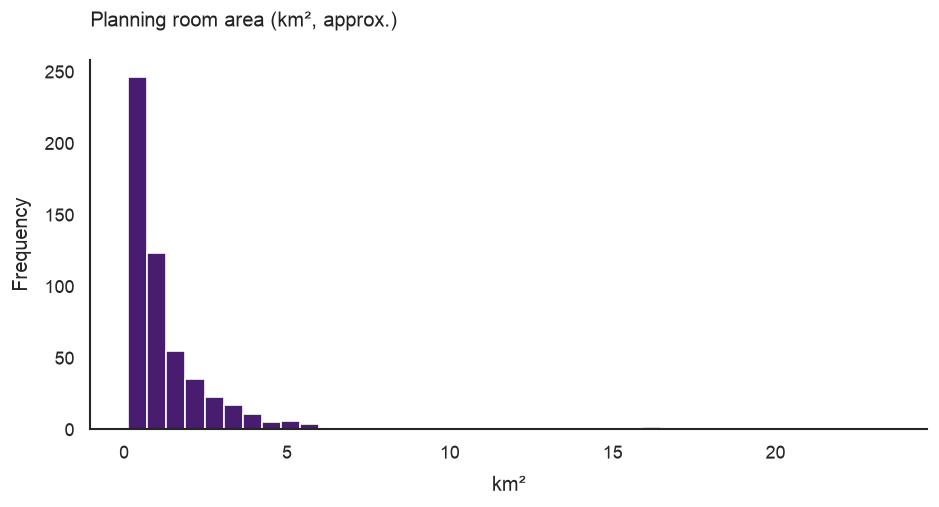

In [5]:
df_area = df_geo.groupby('level')['area_km2'].describe(percentiles=[.25, .5, .75]).round(2).reset_index()
show_df(df_area)
ax = df_geo[df_geo['level'] == 'planning_room']['area_km2'].plot(kind='hist', bins=40, figsize=(9, 4), title='Planning room area (km², approx.)')
ax.set_xlabel('km²')

## What Geometry Adds

Aus den Polygonen lassen sich Merkmale ableiten, die in keiner BF-Quelle stehen: Fläche, Einsatzdichte (Einsätze je km²) und Abstand zum Zentrum (Näherung für "Randlage"). Erste Zusammenhänge mit der offiziellen Quote und der Antwortzeit je Planungsraum (nur Regionen mit mindestens 30 auswertbaren kritischen Einsätzen). Rangkorrelation, keine Ursachen.

In [6]:
df_f = q("""
    select data_year as year, region_id, mission_count_all, ems_critical_timegoal_quote as quote,
           response_time_ems_critical_median as median_s, ems_critical_timegoal_computed as n
    from fct_timegoal_region_yearly where region_level = 'planning_room' and ems_critical_timegoal_computed >= 30
""").merge(df_geo[df_geo['level'] == 'planning_room'][['region_id', 'area_km2', 'dist_centre_km']], on='region_id')
df_f['missions_per_km2'] = df_f['mission_count_all'] / df_f['area_km2']
rank = lambda s: s.rank()
rows = []
for year, g in df_f.groupby('year'):
    for feat in ['dist_centre_km', 'missions_per_km2', 'area_km2']:
        rows.append({'year': year, 'feature': feat, 'regions': len(g),
                     'rank_corr_with_quote': round(rank(g[feat]).corr(rank(g['quote'])), 2),
                     'rank_corr_with_median_s': round(rank(g[feat]).corr(rank(g['median_s'])), 2)})
show_df(pd.DataFrame(rows))

,year,feature,regions,rank_corr_with_quote,rank_corr_with_median_s
0,2024,dist_centre_km,538,-0.46,0.46
1,2024,missions_per_km2,538,0.53,-0.54
2,2024,area_km2,538,-0.44,0.44
3,2025,dist_centre_km,538,-0.49,0.46
4,2025,missions_per_km2,538,0.54,-0.53
5,2025,area_km2,538,-0.44,0.42
6,2026,dist_centre_km,538,-0.55,0.50
7,2026,missions_per_km2,538,0.58,-0.55
8,2026,area_km2,538,-0.47,0.43


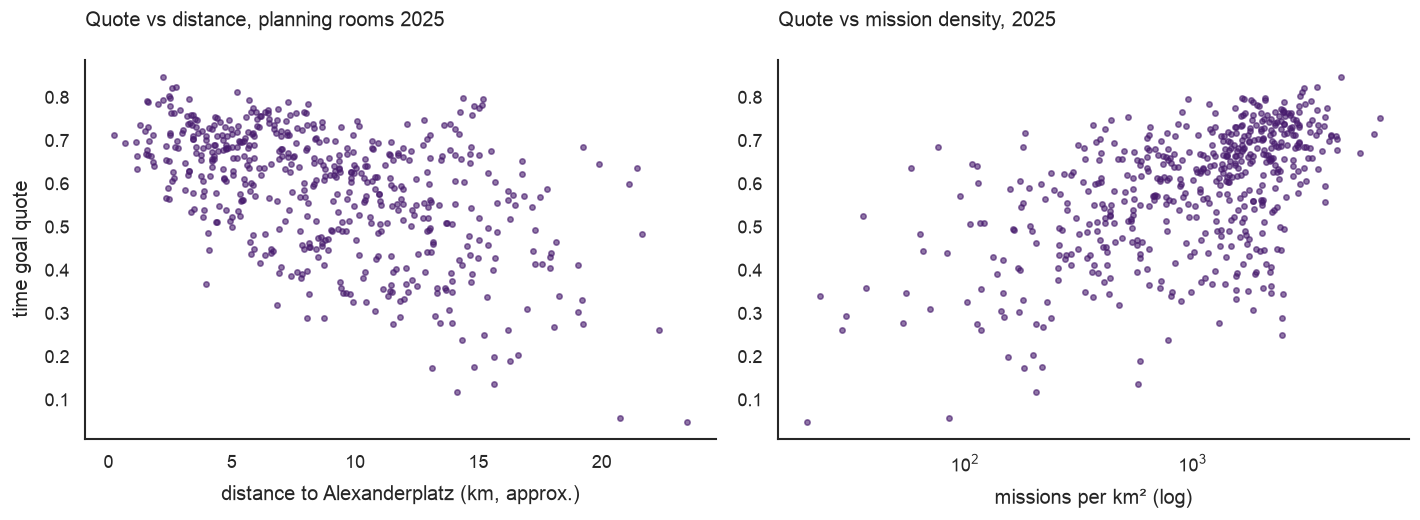

In [7]:
g = df_f[df_f['year'] == 2025]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(g['dist_centre_km'], g['quote'], s=10, alpha=0.6); axes[0].set_xlabel('distance to Alexanderplatz (km, approx.)'); axes[0].set_ylabel('time goal quote'); axes[0].set_title('Quote vs distance, planning rooms 2025')
axes[1].scatter(g['missions_per_km2'], g['quote'], s=10, alpha=0.6); axes[1].set_xscale('log'); axes[1].set_xlabel('missions per km² (log)'); axes[1].set_title('Quote vs mission density, 2025')
plt.tight_layout()

In [8]:
df_bins = g.assign(distance_band=pd.cut(g['dist_centre_km'], [0, 3, 6, 9, 12, 30]))
df_bins = df_bins.groupby('distance_band', observed=True).agg(regions=('region_id', 'count'), median_quote=('quote', 'median'), median_response_s=('median_s', 'median')).round(2).reset_index()
show_df(df_bins)

,distance_band,regions,median_quote,median_response_s
0,"(0, 3]",44,0.70,543.00
1,"(3, 6]",129,0.68,566.00
2,"(6, 9]",116,0.64,573.75
3,"(9, 12]",111,0.57,604.00
4,"(12, 30]",138,0.50,632.00


## Reproducibility

In [9]:
raw_path = PATHS['raw'] / 'geo' / 'lor_wfs.json'
if raw_path.exists():
    raw = json.loads(raw_path.read_text(encoding='utf-8'))
    raw_area = {f['properties']['thematicId']['identifier']: f['properties']['areaValue']['value'] / 1e6 for f in raw['features']}
    cmp = df_geo.assign(raw_area_km2=df_geo['region_id'].map(raw_area))
    cmp['diff_pct'] = (cmp['area_km2'] / cmp['raw_area_km2'] - 1) * 100
    show_df(cmp.groupby('level')['diff_pct'].agg(['min', 'median', 'max']).round(2).reset_index())
else:
    warn('data/raw/geo/lor_wfs.json missing — run `make geo` to compare against the unsimplified source')

,level,min,median,max
0,district_area,-1.11,-0.83,-0.53
1,planning_room,-1.19,-0.83,-0.48
2,prediction_area,-1.08,-0.81,-0.53


## Findings

### Content

Flächen der Berliner LOR (Stand 01.01.2021) auf drei Ebenen: 58 Prognoseräume, 143 Bezirksregionen, 542 Planungsräume, aus dem WFS des Geoportals Berlin (Amt für Statistik Berlin-Brandenburg, CC BY 3.0 DE), vereinfacht auf rund 2 m Toleranz und je Ebene als GeoJSON gespeichert.

### Usefulness

* **Karte:** Alle Regionen der Regionaldaten haben eine Fläche; die IDs passen exakt, die Hierarchie ist ohne Verstoß.
* **Abgeleitete Merkmale**, die in keiner BF-Quelle stehen: Fläche, Einsatzdichte, Abstand zum Zentrum. Sie geben uns eine erste Prüfung der Hypothese "Randlage und Dichte hängen mit der Antwortzeit zusammen".
* **Keine Zusatzbeschaffung nötig** für die Karte; für Abstände zu Wachen bräuchten wir deren Koordinaten (siehe `01_exploration_turnout`).

### Limits

* **Stichtag 2021.** Für die Regionaldaten 2024 bis 2026 passt der Gebietsstand (IDs decken sich), spätere Gebietsänderungen würden wir nicht sehen.
* **Vereinfachte Geometrie.** Flächen liegen im Median rund 0,8 % unter denen der ungekürzten Quelle (Vereinfachung plus Gradnäherung); für Dichten und Entfernungen ist das ausreichend, für Vermessung nicht.
* **Der Abstand zum Alexanderplatz ist eine grobe Näherung für "Randlage"** (Luftlinie zum Flächenschwerpunkt). Er sagt nichts über Wachenstandorte oder Straßennetz.
* **Zusammenhänge auf Regionsebene** (Aggregate je Planungsraum und Jahr), nicht auf Einsatzebene; Schlüsse auf einzelne Einsätze sind nicht zulässig.
* **Namen:** Vier Planungsräume heißen bei BF anders als in den LOR, bei zweien (IDs 12500926 und 12500930) sind die Namen vertauscht. Die ID ist maßgeblich.
* **Lizenz:** CC BY 3.0 DE verlangt den Quellenvermerk; er steht in App und README.

### Observations

Stand der Ausführung. Zusammenhänge, keine Ursachen.

| Beobachtung | Beleg im Notebook |
|---|---|
| Alle 743 Flächen sind gültig; je Ebene decken sie dieselbe Gesamtfläche ab; je Ebene sind genau zwei Flächen mehrteilig | Load Polygons |
| Die IDs von Geometrie und Regionaldaten stimmen auf allen Ebenen vollständig überein | Match with the Regional Data |
| Planungsräume sind klein (Median unter 1 km²), Prognoseräume groß (Median rund 12 km²) | Size of Regions |
| Je weiter eine Region vom Zentrum liegt, desto niedriger die offizielle Quote und desto länger die Antwortzeit (Rangkorrelation rund −0,5 bzw. +0,5, in allen drei Jahren) | What Geometry Adds |
| Dichte wirkt ähnlich stark in die andere Richtung: mehr Einsätze je km², höhere Quote und kürzere Zeit (rund +0,55 bzw. −0,55) | What Geometry Adds |
| In Abstandsbändern: Median der Quote von rund 70 % (bis 3 km) auf rund 50 % (über 12 km), Median der Antwortzeit von rund 543 s auf rund 632 s | What Geometry Adds |
| Die Vereinfachung kostet im Median rund 0,8 % Fläche gegenüber der ungekürzten Quelle (liegt `data/raw/geo` lokal vor) | Reproducibility |

### Open Questions

* **`02_preparation`:** Geometrie-Merkmale (Fläche, Schwerpunkt, Abstand) als dbt-Seed oder Mart `dim_region_geo` ablegen? Vorschlag: Seed aus einem Skript, damit die Pipeline deterministisch bleibt.
* **`03_analysis_geo`:** Trennen sich Dichte, Randlage und Region (Bezirk) voneinander, oder erfassen sie dasselbe? Einfache Regression oder partielle Rangkorrelation auf Planungsräumen; Bezirke als Kontrolle.
* **Anreicherung Stufe 2:** Einwohner je Planungsraum (Einsätze je Einwohner statt je km²) und Wachen-Koordinaten (Abstand zur nächsten Wache) prüfen; Quelle und Lizenz klären.
* **Namensabweichungen (BACKLOG 14):** In `dim_region` den LOR-Namen als maßgeblich führen und den BF-Namen als Zusatzspalte behalten.